This cell imports the `kagglehub` library and downloads the "arabic-sentiment-twitter-corpus" dataset directly from Kaggle, saving the path to the downloaded files in the `path` variable.

In [78]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mksaad/arabic-sentiment-twitter-corpus")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\hp\.cache\kagglehub\datasets\mksaad\arabic-sentiment-twitter-corpus\versions\2


Here, i imported the necessary Python libraries for data manipulation (`pandas`, `numpy`), data visualization (`matplotlib.pyplot`, `seaborn`), and string/regex operations (`re`, `string`). It also quietly installs the `emoji` package, which will be used later to handle emojis in the tweets.

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
!pip install emoji -q


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


This cell loads the dataset files. It reads the positive and negative training and testing TSV (Tab-Separated Values) files into separate Pandas DataFrames. `header=None` is used because the raw files do not contain column names.

In [80]:
train_pos = pd.read_csv(path + "/train_Arabic_tweets_positive_20190413.tsv", sep='\t', header=None)
train_neg = pd.read_csv(path + "/train_Arabic_tweets_negative_20190413.tsv", sep='\t', header=None)
test_pos = pd.read_csv(path + "/test_Arabic_tweets_positive_20190413.tsv", sep='\t', header=None)
test_neg = pd.read_csv(path + "/test_Arabic_tweets_negative_20190413.tsv", sep='\t', header=None)

These cells display the first five rows (`.head()`) of the positive and negative training DataFrames, respectively, allowing us to inspect the raw structure of the imported data.

In [81]:
train_pos.head()

,0,1
0,pos,نحن الذين يتحول كل ما نود أن نقوله إلى دعاء لل...
1,pos,وفي النهاية لن يبقىٰ معك آحدإلا من رأىٰ الجمال...
2,pos,من الخير نفسه 💛
3,pos,#زلزل_الملعب_نصرنا_بيلعب كن عالي الهمه ولا ترض...
4,pos,الشيء الوحيد الذي وصلوا فيه للعالمية هو : المس...


In [82]:
train_neg.head()

,0,1
0,neg,اعترف ان بتس كانو شوي شوي يجيبو راسي لكن اليوم...
1,neg,توقعت اذا جات داريا بشوفهم كاملين بس لي للحين ...
2,neg,#الاهلي_الهلال اكتب توقعك لنتيجة لقاء الهلال و...
3,neg,نعمة المضادات الحيوية . تضع قطرة💧مضاد بنسلين ع...
4,neg,الدودو جايه تكمل علي 💔


To make the data easier to work with, this cell renames the default integer column indices (0 and 1) to descriptive names: "Sentiment" for the labels and "comment" for the tweet text. This is applied to all four DataFrames.

In [83]:
train_pos = train_pos.rename(columns={0: "Sentiment", 1: "comment"})
train_neg = train_neg.rename(columns={0: "Sentiment", 1: "comment"})
test_pos = test_pos.rename(columns={0: "Sentiment", 1: "comment"})
test_neg = test_neg.rename(columns={0: "Sentiment", 1: "comment"})

This cell combines the separated positive and negative DataFrames into a single unified `train_data` DataFrame and a single `test_data` DataFrame using `pd.concat()`.

In [84]:
train_data = pd.concat([train_pos, train_neg])
test_data = pd.concat([test_pos, test_neg])

Displays the newly concatenated `train_data` DataFrame to verify the merge was successful.

In [85]:
train_data

,Sentiment,comment
0,pos,نحن الذين يتحول كل ما نود أن نقوله إلى دعاء لل...
1,pos,وفي النهاية لن يبقىٰ معك آحدإلا من رأىٰ الجمال...
2,pos,من الخير نفسه 💛
3,pos,#زلزل_الملعب_نصرنا_بيلعب كن عالي الهمه ولا ترض...
4,pos,الشيء الوحيد الذي وصلوا فيه للعالمية هو : المس...
...,...,...
22509,neg,كيف ترى أورانوس لو كان يقع مكان القمر ؟ 💙💙 كوك...
22510,neg,احسدك على الايم 💔
22511,neg,لأول مرة ما بنكون سوا 💔
22512,neg,بقله ليش يا واطي 🤔


Since the positive and negative data were concatenated sequentially, this cell shuffles the rows randomly (`frac=1`) to prevent any order bias during model training. It also resets the index so it flows continuously from 0.

In [86]:
#random the data
train_data = train_data.sample(frac=1).reset_index(drop=True)
test_data = test_data.sample(frac=1).reset_index(drop=True)

Displays the `train_data` DataFrame again to confirm that the rows and sentiments are now randomly shuffled.

In [87]:
train_data

,Sentiment,comment
0,neg,كلشوي رينق رينق
1,neg,لاا ايش قومي ،ابغا حل برجع انام 💔
2,neg,لا فعلا غلطانين تصدق 😏
3,pos,حكومة انتقالية بقيادة لجنة امنية عليا ❎ حكومة ...
4,pos,حديث آلبعض يسعدك ، مهمآ كان يومك سيئا ✨
...,...,...
45270,neg,في داخلي غصة بكا موجعتني 😭 يا لعنبوها كم لها غ...
45271,pos,🚨 رسميا : مروان داكوستا سيغيب لمدة تتراوح بين ...
45272,pos,بس برضو لسه بحبها وهفضل جنبها رغم كل الخناقات ...
45273,pos,ربي ياخذ مني ويعطي دغري 😂


These cells output the shape (number of rows and columns) of the `train_data` (45,275 rows) and `test_data` (11,520 rows) DataFrames.

In [88]:
train_data.shape

(45275, 2)

In [89]:
test_data.shape

(11520, 2)

This checks the distribution of the target variable (`Sentiment`) in the training data using `.value_counts()`. It shows that the dataset is perfectly balanced with roughly an equal number of positive and negative tweets.

In [90]:
train_data['Sentiment'].value_counts()

Sentiment
pos    22761
neg    22514
Name: count, dtype: int64

Defines a custom function `normalize_arabic(text)` to standardize Arabic text. It removes Arabic diacritics (Tashkeel) and unifies different variations of letters (e.g., normalizing different forms of Alef to a standard "ا", or Teh Marbuta to Heh) to reduce the vocabulary size and help the model generalize.

In [91]:
def normalize_arabic(text):
  # Remove diacritics
    text = re.sub(r'[\u064B-\u065F\u0670]', '', text)
  # Normalize letters variations
    text = re.sub("[إٱأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "ء", text)
    text = re.sub("ئ", "ء", text)
    text = re.sub("ة", "ه", text)
    text = re.sub("گ", "ك", text)
    text = re.sub("ڤ", "ف", text)
    text = re.sub("چ", "ج", text)
    text = re.sub("پ", "ب", text)
    text = re.sub("ڜ", "ش", text)
    text = re.sub("ڪ", "ك", text)
    return text

Applies the `normalize_arabic` function to the "comment" column of both the training and testing sets.

In [92]:
train_data['comment'] = train_data['comment'].apply(normalize_arabic)
test_data['comment'] = test_data['comment'].apply(normalize_arabic)

Defines a function `handle_emojis(text, mode)` to manage emojis in the text. It uses the `emoji` library to either completely remove emojis or convert them into descriptive Arabic text (e.g., converting 😂 to its text description), preserving their semantic value.

In [93]:
import emoji

def handle_emojis(text, mode='remove'):
    if mode == 'remove':
        return emoji.replace_emoji(text, '')
    elif mode == 'description':
        return emoji.demojize(text, language='ar')
    return text

In [94]:
train_data['comment'] = train_data['comment'].apply(lambda x: handle_emojis(x, mode='description'))
test_data['comment'] = test_data['comment'].apply(lambda x: handle_emojis(x, mode='description'))

Defines `remove_arabic_noise(text)`, a function that cleans the text by removing "Tatweel" (the Arabic character elongation symbol `ـ`), stripping out HTML tags, and compressing extra whitespaces into single spaces.

In [95]:
def remove_arabic_noise(text):
    # Remove tatweel
    text = re.sub(r'\u0640', '', text)
    # Remove HTML tags
    text = re.sub('<.*?>', '', text)
    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [96]:
train_data['comment'] = train_data['comment'].apply(remove_arabic_noise)
test_data['comment'] = test_data['comment'].apply(remove_arabic_noise)

Displays the training DataFrame to visualize the text transformations applied so far (normalization, emoji conversion, and noise reduction).

In [97]:
train_data

,Sentiment,comment
0,neg,كلشوي رينق رينق
1,neg,لاا ايش قومي ،ابغا حل برجع انام :قلب_مكسور:
2,neg,لا فعلا غلطانين تصدق :وجه_بابتسامة_متكلفة:
3,pos,حكومه انتقاليه بقياده لجنه امنيه عليا :علامة_x...
4,pos,حديث البعض يسعدك ، مهما كان يومك سيءا :ومضات:
...,...,...
45270,neg,في داخلي غصه بكا موجعتني :وجه_يبكي_بكاء_مرتفعا...
45271,pos,:إضاءة_سيارة_شرطة_دوارة: رسميا : مروان داكوستا...
45272,pos,بس برضو لسه بحبها وهفضل جنبها رغم كل الخناقات ...
45273,pos,ربي ياخذ مني ويعطي دغري :وجه_بدموع_فرح:


Defines a function `remove_arabic_punctuations(text)` that combines standard English punctuation marks and Arabic-specific punctuation marks, stripping them entirely from the text strings.

In [98]:
#remove puncatuations
arabic_punctuations = '''`÷×؛<>_()*&^%][ـ،/:"؟.,'{}~¦+|!”…“–ـ'''
english_punctuations = '''!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~'''

all_punctuations = arabic_punctuations + english_punctuations

def remove_arabic_punctuations(text):
    return re.sub(f"[{re.escape(all_punctuations)}]", " ", text)

<>:3: SyntaxWarning: invalid escape sequence '\]'
<>:3: SyntaxWarning: invalid escape sequence '\]'
C:\Users\hp\AppData\Local\Temp\ipykernel_11068\59911164.py:3: SyntaxWarning: invalid escape sequence '\]'
  english_punctuations = '''!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~'''


In [99]:
train_data['comment'] = train_data['comment'].apply(remove_arabic_punctuations)
test_data['comment'] = test_data['comment'].apply(remove_arabic_punctuations)

In [100]:
train_data

,Sentiment,comment
0,neg,كلشوي رينق رينق
1,neg,لاا ايش قومي ابغا حل برجع انام قلب مكسور
2,neg,لا فعلا غلطانين تصدق وجه بابتسامة متكلفة
3,pos,حكومه انتقاليه بقياده لجنه امنيه عليا علامة x...
4,pos,حديث البعض يسعدك مهما كان يومك سيءا ومضات
...,...,...
45270,neg,في داخلي غصه بكا موجعتني وجه يبكي بكاء مرتفعا...
45271,pos,إضاءة سيارة شرطة دوارة رسميا مروان داكوستا...
45272,pos,بس برضو لسه بحبها وهفضل جنبها رغم كل الخناقات ...
45273,pos,ربي ياخذ مني ويعطي دغري وجه بدموع فرح


Defines a function `correct_arabic_text(text)` that uses a predefined dictionary to fix common colloquial misspellings or standardizes common phrases (e.g., mapping 'انشالله' to 'إن شاء الله' and 'لاكن' to 'لكن').

In [101]:
def correct_arabic_text(text):
    corrections = {
        'انشاء الله': 'إن شاء الله',
        'لاكن': 'لكن',
        'انشالله': 'إن شاء الله',
        'هاذا': 'هذا',
    }

    for mistake, correction in corrections.items():
        text = text.replace(mistake, correction)

    return text

In [102]:
train_data['comment'] = train_data['comment'].apply(correct_arabic_text)
test_data['comment'] = test_data['comment'].apply(correct_arabic_text)

Defines `handle_numbers_and_special_chars(text, mode)` to manage numerical digits. Based on the selected mode, it can either strip numbers entirely or translate Arabic/English digits into spelled-out Arabic words (e.g., '1' becomes 'واحد').

In [103]:
def handle_numbers_and_special_chars(text, mode='remove'):
    if mode == 'remove':
        text = re.sub(r'\d+', '', text)
        return text
    elif mode == 'normalize':
        number_map = {
                      '٠': 'صفر',
                      '١': 'واحد',
                      '٢': 'اثنان',
                      '٣': 'ثلاثة',
                      '٤': 'أربعة',
                      '٥': 'خمسة',
                      '٦': 'ستة',
                      '٧': 'سبعة',
                      '٨': 'ثمانية',
                      '٩': 'تسعة',
                      '0': 'صفر',
                      '1': 'واحد',
                      '2': 'اثنان',
                      '3': 'ثلاثة',
                      '4': 'أربعة',
                      '5': 'خمسة',
                      '6': 'ستة',
                      '7': 'سبعة',
                      '8': 'ثمانية',
                      '9': 'تسعة'
                  }
        for arabic, name in number_map.items():
            text = text.replace(arabic, name)
        return text

In [104]:
train_data['comment'] = train_data['comment'].apply(lambda x: handle_numbers_and_special_chars(x, mode='normalize'))
test_data['comment'] = test_data['comment'].apply(lambda x: handle_numbers_and_special_chars(x, mode='normalize'))

Defines a rudimentary `arabizi_to_arabic(text)` function that attempts to map Latin characters (Arabizi) back into standard Arabic letters.

In [105]:
def arabizi_to_arabic(text):
    # This is a simplified conversion. A complete solution would be more complex.
    conversion_dict = {
        'a': 'ا', 'b': 'ب', 't': 'ت', 'th': 'ث', 'g': 'ج', '7': 'ح', 'kh': 'خ',
        'd': 'د', 'th': 'ذ', 'r': 'ر', 'z': 'ز', 's': 'س', 'sh': 'ش', '9': 'ص',
        '6': 'ط', '3': 'ع', 'gh': 'غ', 'f': 'ف', 'q': 'ق', 'k': 'ك', 'l': 'ل',
        'm': 'م', 'n': 'ن', 'h': 'ه', 'w': 'و', 'y': 'ي'
    }

    for latin, arabic in conversion_dict.items():
        text = text.replace(latin, arabic)

    return text

In [106]:
train_data['comment'] = train_data['comment'].apply(arabizi_to_arabic)
test_data['comment'] = test_data['comment'].apply(arabizi_to_arabic)

Defines a function `normalize_elongated_words(text)` using Regular Expressions to fix character elongation (e.g., turning "جمييييييل" into "جمييل"). It reduces any character repeated more than twice down to exactly two characters.

In [107]:
def normalize_elongated_words(text):
    # Remove elongation
    text = re.sub(r'(.)\1+', r'\1\1', text)
    return text

In [108]:
train_data['comment'] = train_data['comment'].apply(normalize_elongated_words)
test_data['comment'] = test_data['comment'].apply(normalize_elongated_words)

Installs the NLTK (Natural Language Toolkit) library and downloads necessary NLTK corpora, specifically the 'stopwords' and 'punkt' tokenizer models required for text splitting.

In [109]:
!pip -q install nltk
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt_tab')


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

Applies `word_tokenize` to the comment column, splitting the continuous string of text in each row into a list of individual words (tokens).

In [110]:
train_data['comment'] = train_data['comment'].apply(lambda x: word_tokenize(x))
test_data['comment'] = test_data['comment'].apply(lambda x: word_tokenize(x))

Displays the dataset to verify that the comments are now represented as lists of word tokens.

In [111]:
train_data

,Sentiment,comment
0,neg,"[كلشوي, رينق, رينق]"
1,neg,"[لاا, ايش, قومي, ابغا, حل, برجع, انام, قلب, مك..."
2,neg,"[لا, فعلا, غلطانين, تصدق, وجه, بابتسامة, متكلفة]"
3,pos,"[حكومه, انتقاليه, بقياده, لجنه, امنيه, عليا, ع..."
4,pos,"[حديث, البعض, يسعدك, مهما, كان, يومك, سيءا, وم..."
...,...,...
45270,neg,"[في, داخلي, غصه, بكا, موجعتني, وجه, يبكي, بكاء..."
45271,pos,"[إضاءة, سيارة, شرطة, دوارة, رسميا, مروان, داكو..."
45272,pos,"[بس, برضو, لسه, بحبها, وهفضل, جنبها, رغم, كل, ..."
45273,pos,"[ربي, ياخذ, مني, ويعطي, دغري, وجه, بدموع, فرح]"


Loads the NLTK Arabic stopwords list and applies a lambda function to filter these words out of the tokenized comments. Stopwords are common words (like "في", "من", "على") that do not carry significant meaning for sentiment analysis.

In [112]:
arabic_stopwords = set(stopwords.words('arabic'))
train_data['comment'] = train_data['comment'].apply(lambda x: [word for word in x if word not in arabic_stopwords])
test_data['comment'] = test_data['comment'].apply(lambda x: [word for word in x if word not in arabic_stopwords])

In [113]:
train_data

,Sentiment,comment
0,neg,"[كلشوي, رينق, رينق]"
1,neg,"[لاا, ايش, قومي, ابغا, حل, برجع, انام, قلب, مك..."
2,neg,"[فعلا, غلطانين, تصدق, وجه, بابتسامة, متكلفة]"
3,pos,"[حكومه, انتقاليه, بقياده, لجنه, امنيه, عليا, ع..."
4,pos,"[حديث, البعض, يسعدك, يومك, سيءا, ومضات]"
...,...,...
45270,neg,"[داخلي, غصه, بكا, موجعتني, وجه, يبكي, بكاء, مر..."
45271,pos,"[إضاءة, سيارة, شرطة, دوارة, رسميا, مروان, داكو..."
45272,pos,"[برضو, لسه, بحبها, وهفضل, جنبها, رغم, الخناقات..."
45273,pos,"[ربي, ياخذ, مني, ويعطي, دغري, وجه, بدموع, فرح]"


Imports and initializes the `ISRIStemmer` from NLTK. This is an Arabic-specific stemmer designed to reduce words to their base linguistic roots.

In [114]:
from nltk.stem.isri import ISRIStemmer
stemmer = ISRIStemmer()

In [115]:
# train_data['comment'] = train_data['comment'].apply(lambda x: [stemmer.stem(word) for word in x])
# test_data['comment'] = test_data['comment'].apply(lambda x: [stemmer.stem(word) for word in x])

Uses Scikit-Learn's `LabelEncoder` to convert the categorical target variables ("pos" and "neg") into binary numerical values (e.g., 1 and 0), which is required by machine learning algorithms.

In [116]:
train_data['Sentiment'] = train_data['Sentiment'].astype(str)
test_data['Sentiment'] = test_data['Sentiment'].astype(str)

from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
encoder.fit(pd.concat([train_data['Sentiment'], test_data['Sentiment']]).unique())

train_data['Sentiment'] = encoder.transform(train_data['Sentiment'])
test_data['Sentiment'] = encoder.transform(test_data['Sentiment'])

Generates a pie chart visualizing the distribution of the "Sentiment" labels in the training data, confirming a perfectly balanced dataset (50.3% positive, 49.7% negative).

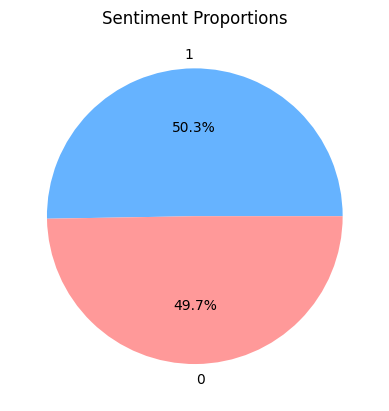

In [117]:
train_data['Sentiment'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999','#99ff99'])
plt.title("Sentiment Proportions")
plt.ylabel("")  # hide y-label
plt.show()

Imports the final machine learning tools from Scikit-Learn: `TfidfVectorizer` for feature extraction, `LogisticRegression` for the classification algorithm, and metrics (`accuracy_score`, `classification_report`) for evaluating the model.

In [118]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

First, it joins the list of tokens back into single strings. Then, it initializes a `TfidfVectorizer` (capturing up to 20,000 top unigrams and bigrams) and transforms the text into numerical feature matrices (`X_train` and `X_test`). Target labels are assigned to `y_train` and `y_test`.

In [119]:
train_data['comment'] = train_data['comment'].apply(lambda x: ' '.join(x))
test_data['comment'] = test_data['comment'].apply(lambda x: ' '.join(x))

vectorizer = TfidfVectorizer(max_features=20000, min_df=2, max_df=0.95, ngram_range=(1,2))
X_train = vectorizer.fit_transform(train_data['comment'])
X_test = vectorizer.transform(test_data['comment'])
y_train = train_data['Sentiment']
y_test = test_data['Sentiment']

# Logistic Regresiion

Initializes a Logistic Regression model and fits it to the TF-IDF training data. It then predicts on both the training and testing sets, printing out the Accuracy and a detailed Classification Report (Precision, Recall, F1-Score) for both sets. The model achieves an impressive ~92.4% accuracy on unseen test data.

In [154]:
model = LogisticRegression(C=0.5, max_iter=1000)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Train Accuracy: {train_accuracy}")
print(classification_report(y_train, y_train_pred))

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

Train Accuracy: 0.9356156819436775
              precision    recall  f1-score   support

           0       0.96      0.91      0.93     22514
           1       0.92      0.96      0.94     22761

    accuracy                           0.94     45275
   macro avg       0.94      0.94      0.94     45275
weighted avg       0.94      0.94      0.94     45275

Accuracy: 0.92421875
              precision    recall  f1-score   support

           0       0.95      0.90      0.92      5768
           1       0.90      0.95      0.93      5752

    accuracy                           0.92     11520
   macro avg       0.93      0.92      0.92     11520
weighted avg       0.93      0.92      0.92     11520



Calculates the Confusion Matrix for the test predictions and plots it as a heatmap using `seaborn`. This visualizes how many True Positives, True Negatives, False Positives, and False Negatives the model produced.

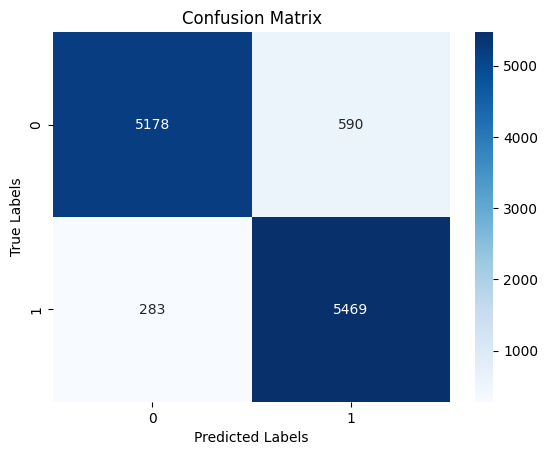

In [155]:
#display confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


Extracts the raw probability scores outputted by the model and plots a histogram. This shows the distribution of the model's confidence in predicting positive sentiment.

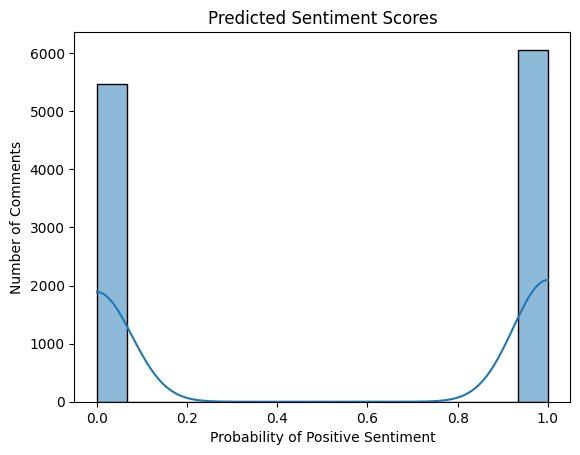

In [156]:
y_probs = model.predict(X_test).flatten()
sns.histplot(y_probs, bins=15, kde=True)
plt.title("Predicted Sentiment Scores")
plt.xlabel("Probability of Positive Sentiment")
plt.ylabel("Number of Comments")
plt.show()

Uses `joblib` to save (serialize) both the trained Logistic Regression model and the fitted TF-IDF vectorizer to disk in a `models` directory. This allows the model to be loaded and deployed later without needing to retrain it.

In [157]:
from pathlib import Path
import joblib

BASE_DIR = Path().resolve().parent

models_dir = BASE_DIR / "models"
models_dir.mkdir(exist_ok=True)

joblib.dump(model, models_dir / "sentiment_model.pkl")
joblib.dump(vectorizer, models_dir / "tfidf_vectorizer.pkl")

['D:\\py\\Arabic Sentiment analysis\\arabic-sentiment-analyzer\\models\\tfidf_vectorizer.pkl']

Takes a random subset of 60 comments from the testing dataset and saves it to a file named `test_subset.csv`. This is useful for manual inspection or quick external testing of the deployed model.

In [158]:
#take subset of 100 comment only from the test_data
test_subset = test_data['comment'].sample(n=60)
test_subset.to_csv("test_subset.csv", index=False)